In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler


# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 04


## Exercise 04.1

### Assignment

In Statistical Mechanics the Maxwell–Boltzmann distribution is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

Include the calculation of the Maxwell–Boltzmann distribution $$p(v^*,T^*)$$ inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.

## Exercise 04.2
### Assignment

By means of your upgraded code, **perform MD simulations via a Lennard-Jones model** (e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- **gas phase**: $\rho^\star = 0.05$, $T^\star \sim 2.0$ (cut-off radius: $r_c = 5.0$)

starting from a **very low entropic** initial configuration:
1. initial **particle positions**: fcc crystal occupying half of the simulation box in each dimension
2. initial **velocity distribution**: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$ where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

### Solution

The code for this exercise is structured in this way:
- NSL_SIMULATOR.cpp (`main`): here i create an object "`System`", the core class of the simulation. I call the methods to initialize it and i execute the simulation in a double loop, in order to get the data for data blocking.
- `System`: here are stored all the important variables and methods for the simulation. I added:
    - the method to calculate the velocity distribution:
        ```c++
        if (_measure_pofv){
            for (int i=0; i<_npart; i++){
                double v_temp = _particle(i).getmodvelocity(); // Get module of v for the i-th particle
                int bin_index_v = static_cast<int>(v_temp / _bin_size_v); // Find in which bin falls v
                if (bin_index_v >= _n_bins_v) overflow_count_v++; // Overflow count
                else _measurement(_index_pofv + bin_index_v) += 1.0; // I store the data in _measurement vector, from _index_pofv to _index_pofv + _n_bins_v
            }
        }
        ```
    - a trivial algorithm to extract a random direction for the velocity:
        ```c++
        double v_star = sqrt(3*_temp);
        for (int i=0; i<_npart; i++){
            int b = static_cast<int>(_rnd.Rannyu(0, 3));      // Direction (3 possibilities)
            int segno = (_rnd.Rannyu() > 0.5) ? 1.0 : -1.0;   // To extract + or - (2 possibilities)
            if (b == 0) vx(i) = v_star * double(segno); 
            else if (b == 1) vy(i) = v_star * double(segno); 
            else vz(i) = v_star * double(segno);
            
            sumv(0) += vx(i);
            sumv(1) += vy(i);
            sumv(2) += vz(i);
        }
        ```
    - `_reverse`: flag for reversing time in the sim.
    - in initialize_properties i implemented a way to set the initial position to half.
        ```c++
        _particle(i).setposition(0, this->pbc(_halfside(0)*x, 0));
        _particle(i).setposition(1, this->pbc(_halfside(1)*y, 1));
        _particle(i).setposition(2, this->pbc(_halfside(2)*z, 2));
        ```
- `Particle`: here are saved other variables relatively to the particle itself. I added the method `getmodvelocity()`: calling it every time slows slightly the code, but i sacrificed extreme speed for readability.
The code, and input/output data are organized in three folders: `SOURCE`, `INPUT`, `OUTPUT`.



For this analysis, I am utilizing data stored in a dedicated directory named **`"OUTPUT_4.2_def"`**, obtained from a simulation consisting of 100 blocks with 100 steps per block. The simulation starts from an FCC crystalline configuration scaled by a factor of 0.5. Random initial velocities are assigned along one axis using the preceding script.

I plot the distribution evolution through a few selected blocks. First, I plot the value of each individual block—which exhibits larger statistical fluctuations as it represents the average over a single block—followed by the progressive average to highlight the convergence of the distribution.

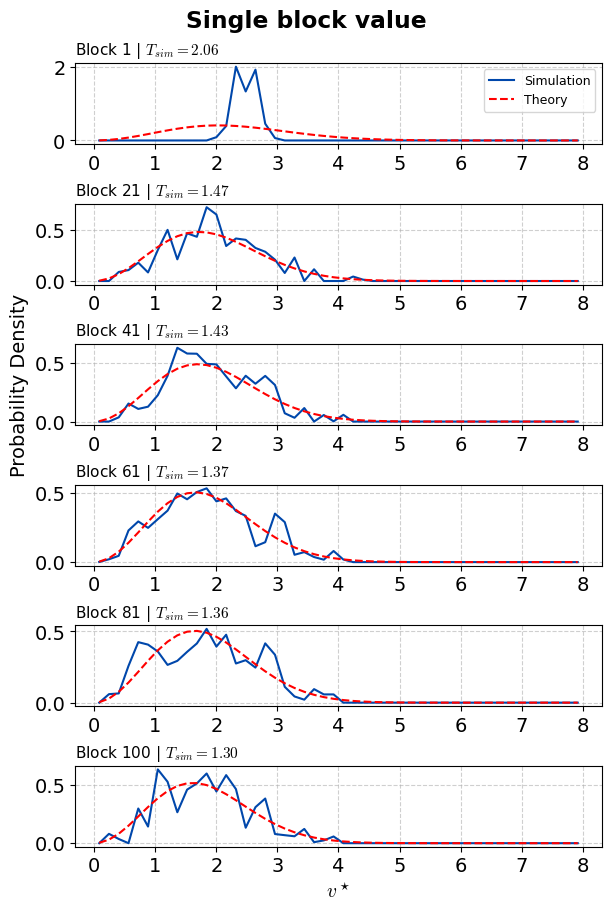

In [ ]:
# Define the theoretical Maxwell-Boltzmann distribution for speeds (reduced units, m=1)
def maxwell_boltzmann(v, T):
    return np.sqrt(2 / np.pi) * (v**2 / T**1.5) * np.exp(-(v**2) / (2 * T))

# Helper function to extract parameters from text files
def extract_parameter(filepath, keyword):
    with open(filepath, "r") as file:
        # Read the entire file and split it into a list of tokens
        tokens = file.read().split()
    try:
        # Find the index of the keyword and return the next element as an integer
        idx = tokens.index(keyword)
        return int(tokens[idx + 1])
    except ValueError:
        print(f"Error: Keyword '{keyword}' not found in {filepath}")
        return None
    except IndexError:
        print(f"Error: Value missing after keyword '{keyword}' in {filepath}")
        return None

# Extract configuration parameters
n_blks = extract_parameter("NSL_SIMULATOR/OUTPUT_4.2/output.dat", "NBLOCKS=")

# Load simulation data
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/pofv.dat")
T_data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/temperature.dat")

# Calculate n_bins_v
len_data=len(data[:, 0])
n_bins_v= int(len_data/n_blks)

# Figure setup: 6 rows, 1 column
fig, ax = plt.subplots(6, 1, figsize=(6, 9), constrained_layout=True)

count = 0
delta_x = data[1, 0] - data[0, 0]

# Loop over the blocks to plot a selection of them
for i in range(n_blks):
    # Select every 20th block, plus the very last one. 
    # Safety check to avoid exceeding the axes array bounds.
    if (i % 20 == 0 or i == n_blks - 1) and count < len(ax): 
        inizio = i * n_bins_v
        fine = inizio + n_bins_v
        
        # Extract x and y data for the current block
        x = data[inizio:fine, 0]
        y = data[inizio:fine, 1]
        
        # Normalize the empirical probability density function (PDF)
        norm_fac = np.sum(y) * delta_x
        y_pdf = y / norm_fac
        
        # Extract the instantaneous temperature for the theoretical curve
        current_T = T_data[i, 1]
        
        # Plot on the corresponding subplot
        ax[count].plot(x, y_pdf, linewidth=1.5, label='Simulation')
        ax[count].plot(x, maxwell_boltzmann(x, current_T), 
                       linestyle='--', linewidth=1.5, label='Theory')

        # Subplot formatting
        ax[count].set_title(rf"Block {i+1} | $T_{{sim}} = {current_T:.2f}$", loc='left', fontsize=11)
        ax[count].grid(True, linestyle='--', alpha=0.6)
        ax[2].set_ylabel("Probability Density")
        
        # Add legend only to the first subplot to keep the figure clean
        if count == 0:
            ax[count].legend(loc='upper right', fontsize=9)
            
        count += 1

# Common X-axis label (applied only to the bottom subplot for a cleaner look)
ax[-1].set_xlabel(r"$v^\star$")

fig.suptitle('Single block value', fontweight='bold')

plt.show()

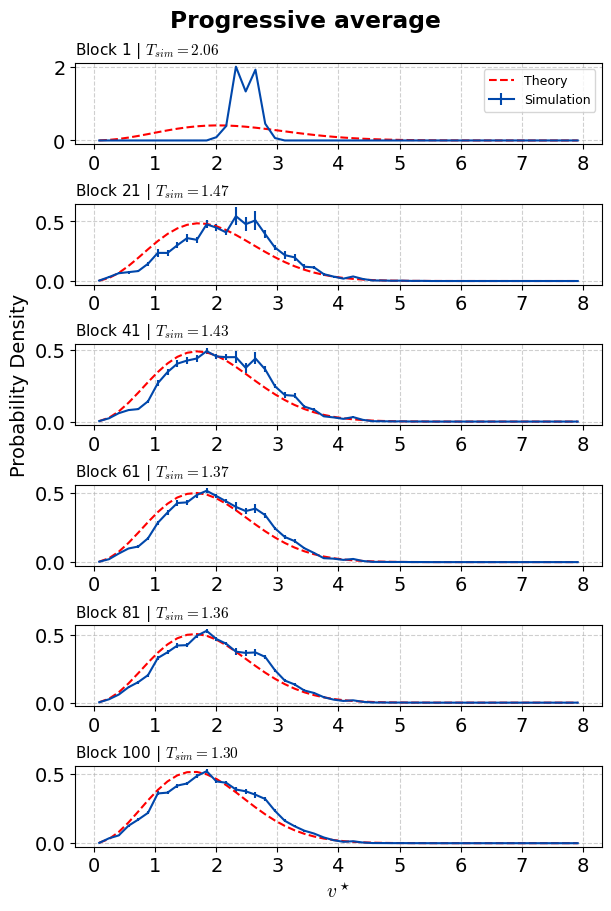

In [ ]:
# Figure setup: 6 rows, 1 column
fig, ax = plt.subplots(6, 1, figsize=(6, 9), constrained_layout=True)

count = 0
delta_x = data[1, 0] - data[0, 0]

# Loop over the blocks to plot a selection of them
for i in range(n_blks):
    # Select every 20th block, plus the very last one. 
    # Safety check to avoid exceeding the axes array bounds.
    if (i % 20 == 0 or i == n_blks - 1) and count < len(ax): 
        inizio = i * n_bins_v
        fine = inizio + n_bins_v
        
        # Extract x and y data for the current block
        x = data[inizio:fine, 0]
        y = data[inizio:fine, 2]
        errore = data[inizio:fine, 3]
        
        # Normalize the empirical probability density function (PDF)
        norm_fac = np.sum(y) * delta_x
        y_pdf = y / norm_fac
        
        # Extract the instantaneous temperature for the theoretical curve
        current_T = T_data[i, 1]
        
        # Plot on the corresponding subplot
        ax[count].errorbar(x, y_pdf, errore/norm_fac,linewidth=1.5, label='Simulation')
        ax[count].plot(x, maxwell_boltzmann(x, current_T),
                       linestyle='--', linewidth=1.5, label='Theory')

        # Subplot formatting
        ax[count].set_title(rf"Block {i+1} | $T_{{sim}} = {current_T:.2f}$", loc='left', fontsize=11)
        ax[count].grid(True, linestyle='--', alpha=0.6)
        ax[2].set_ylabel("Probability Density")
        
        # Add legend only to the first subplot to keep the figure clean
        if count == 0:
            ax[count].legend(loc='upper right', fontsize=9)
            
        count += 1

# Common X-axis label (applied only to the bottom subplot for a cleaner look)
ax[-1].set_xlabel(r"$v^\star$")

fig.suptitle('Progressive average', fontweight='bold')

plt.show()

I chose to plot both the single block value (first image) and the progressive average (second image). From the first one it is clearly visible how the distribution is sharply peaked on a couple values at first, and then it settles around the theorical Blotzmann distribution. In the second image this is even clearer, because of the increasing number of data that pulls the distribution towards the theoretical value. It is also possible to see how the initial values, peaked around v=2.5, distort the following plots, leaving a "bump" in the average value around 2.5.

### Energy and temperature visualization

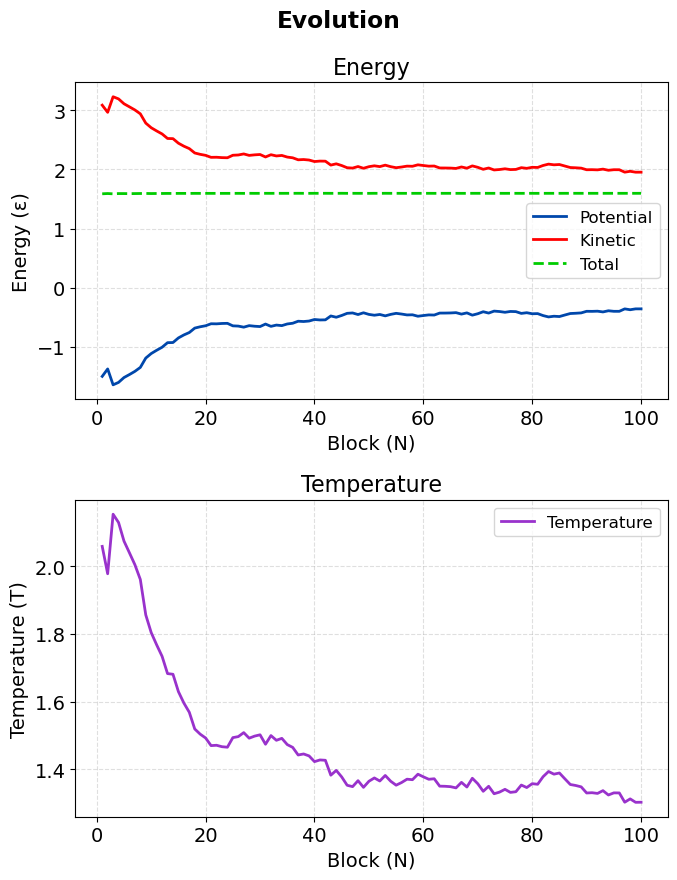

In [ ]:
# Take data
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/potential_energy.dat")
blocks = data[:, 0]
actual_penergy = data[:, 1]
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/kinetic_energy.dat")
actual_kenergy = data[:, 1]
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/total_energy.dat")
actual_tenergy = data[:, 1]
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.2/temperature.dat")
actual_temperature = data[:, 1]


fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 9))
fig.suptitle('Evolution', fontweight='bold')

axes[0].plot(blocks, actual_penergy, label='Potential')
axes[0].plot(blocks, actual_kenergy, label='Kinetic')
axes[0].plot(blocks, actual_tenergy, label='Total', linestyle='--')
axes[0].set_title('Energy')
axes[0].set_xlabel('Block (N)')
axes[0].set_ylabel('Energy (ε)')
axes[0].legend(loc='best', frameon=True)

###
axes[1].plot(blocks, actual_temperature, label='Temperature', color=light_colors[3])
axes[1].set_title('Temperature')
axes[1].set_xlabel('Block (N)')
axes[1].set_ylabel('Temperature (T)')
axes[1].legend(loc='best', frameon=True)
fig.tight_layout()

We can observe that, as expected, total energy is conserved in the simulation, while cinetic energy, potential energy and temperature aren't. Quite the opposite, they start far from equilibrium, and then they settle around a stable point. In particular, cinetic energy is maximum at the start, and then it decreases since the potential energy increases on the other side, due to the chaotic motion of particles. Since T is directly related to kinetic energy, it follows the same evolution.

## Exercise 04.3
### Assignment

Starting from the **final states** of two MD simulations of the system in Exercise 04.2, one with about $5\times 10^3$ time-steps the other with about $5\times 10^4$ time-steps, by changing the direction of time (e.g. by inverting the final velocities, i.e. ... ), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

### Solution

In order to reverse the time in evolution I implemented the flag `_reverse` that inverts the reading of coordinates and old coordinates in the `_restart` method. This way the system evolves autonomously in what seems to be the "reverse time".

```c++
void System :: initialize_velocities(){
    double xold, yold, zold;
    if(_restart){
        ifstream cinf;
        if(_reverse){
            cinf.open("../INPUT/CONFIG/config.xyz"); // To reverse time just read the config file
        }
        else{
            cinf.open("../INPUT/CONFIG/conf-1.xyz"); // Normal time
        } 
        if(cinf.is_open()){
            // ...
            for(int i=0; i<_npart; i++){
            cinf >> particle >> xold >> yold >> zold; // Units of coordinates in conf.xyz is _side
            _particle(i).setpositold(0, this->pbc(_side(0)*xold, 0));
            _particle(i).setpositold(1, this->pbc(_side(1)*yold, 1));
            _particle(i).setpositold(2, this->pbc(_side(2)*zold, 2));
            }
            // ...
        }
    }
}

void System :: read_configuration(){
    ifstream cinf;
    if(_reverse){
    cinf.open("../INPUT/CONFIG/conf-1.xyz"); // To reverse time just read the conf-1 file
    }
    else{
    cinf.open("../INPUT/CONFIG/config.xyz"); // Normal time
    }
    if(cinf.is_open()){
        // ...
        for(int i=0; i<_npart; i++){
            cinf >> particle >> x >> y >> z; // Units of coordinates in conf.xyz is _side
            _particle(i).setposition(0, this->pbc(_side(0)*x, 0));
            _particle(i).setposition(1, this->pbc(_side(1)*y, 1));
            _particle(i).setposition(2, this->pbc(_side(2)*z, 2));
        }
        // ...
    }
}

```

To test the reversed time, I performed two Molecular Dynamic simulations with the following parameters:
- TEMPERATURE = 2
- NPART = 108
- R_CUT= 5
- DELTA= 0.001
- NBLOCKS= 50
    
The first simulation completes 100 steps for 50 blocks, for a total of 5'000 steps. The second one performs 1000 steps for 50 block, for a total of 50'000 steps.

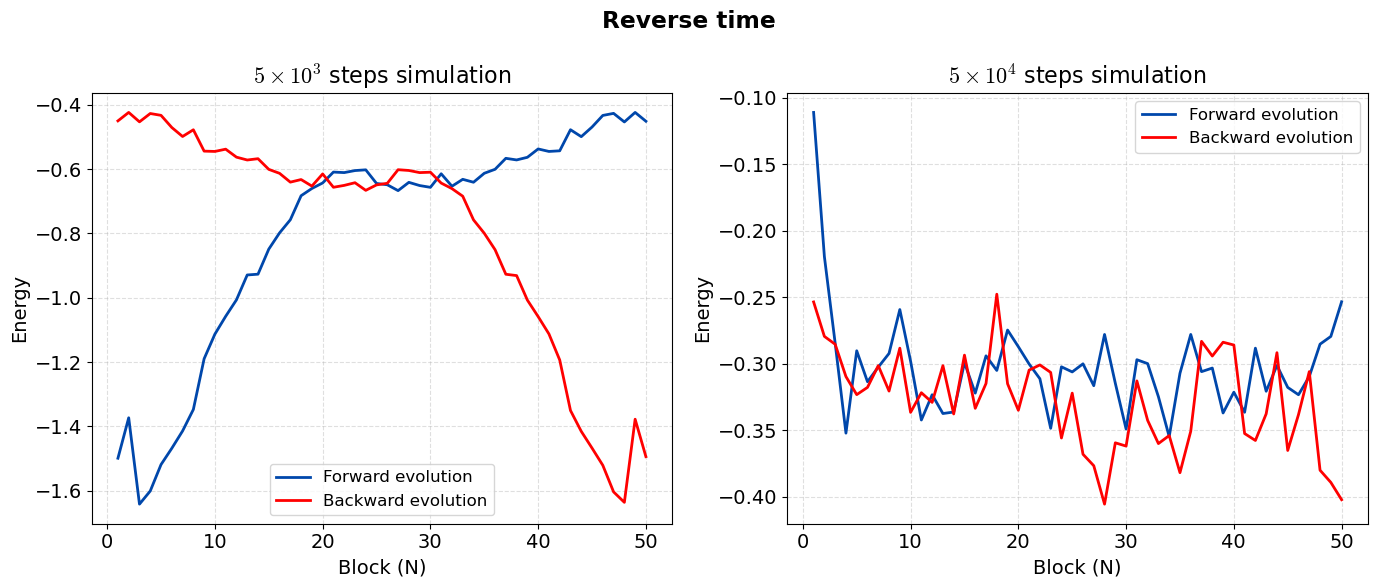

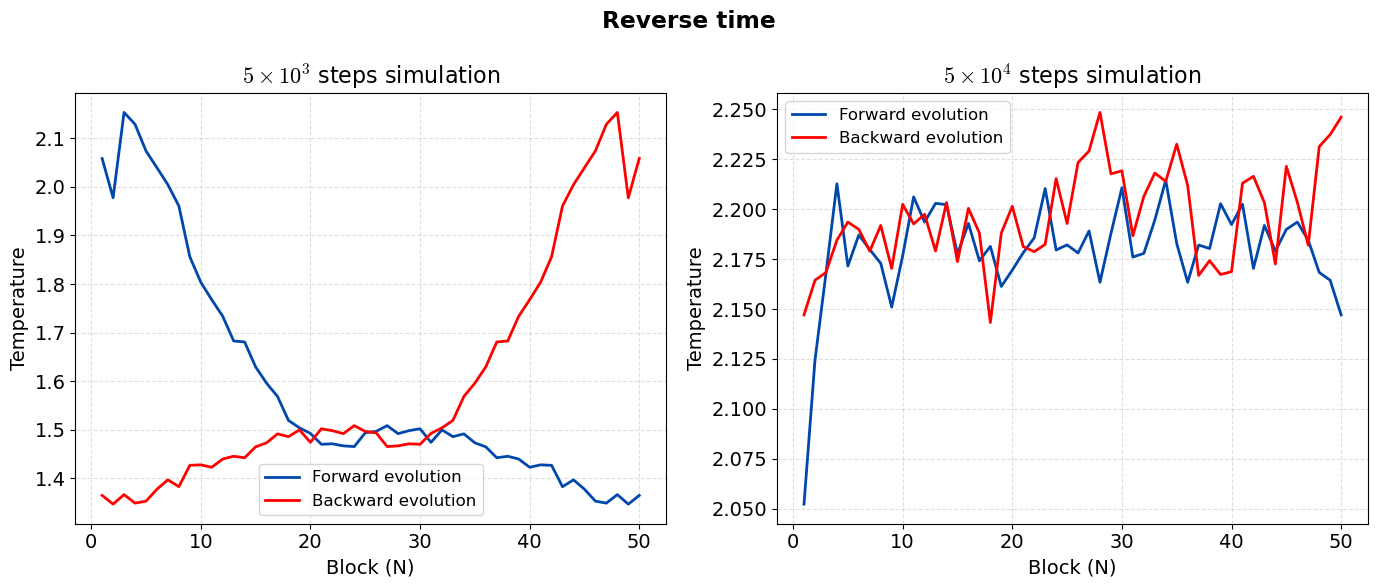

In [ ]:
# Entra per prendere i dati di pofv
data1 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_fwd_5k/potential_energy.dat")
data2 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_bkw_5k/potential_energy.dat")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle('Reverse time', fontweight='bold')

short_blocks = data1[:, 0]
short_te_forward = data1[:, 1]
short_te_backward = data2[:, 1]

axes[0].plot(short_blocks, short_te_forward, label='Forward evolution')
axes[0].plot(short_blocks, short_te_backward, label='Backward evolution')
axes[0].set_title(r'$5 \times 10^3$ steps simulation')
axes[0].set_xlabel('Block (N)')
axes[0].set_ylabel('Energy')
axes[0].legend(loc='best', frameon=True)

data1 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_fwd_50k/potential_energy.dat")
data2 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_bkw_50k/potential_energy.dat")

long_blocks = data1[:, 0]
long_te_forward = data1[:, 1]
long_te_backward = data2[:, 1]

axes[1].plot(long_blocks, long_te_forward, label='Forward evolution')
axes[1].plot(long_blocks, long_te_backward, label='Backward evolution')
axes[1].set_title(r'$5 \times 10^4$ steps simulation')
axes[1].set_xlabel('Block (N)')
axes[1].set_ylabel('Energy')
axes[1].legend(loc='best', frameon=True)

fig.tight_layout()

#######################
# Second graph
#######################

# Entra per prendere i dati di pofv
data1 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_fwd_5k/temperature.dat")
data2 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_bkw_5k/temperature.dat")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle('Reverse time', fontweight='bold')

short_blocks = data1[:, 0]
short_te_forward = data1[:, 1]
short_te_backward = data2[:, 1]

axes[0].plot(short_blocks, short_te_forward, label='Forward evolution')
axes[0].plot(short_blocks, short_te_backward, label='Backward evolution')
axes[0].set_title(r'$5 \times 10^3$ steps simulation')
axes[0].set_xlabel('Block (N)')
axes[0].set_ylabel('Temperature')
axes[0].legend(loc='best', frameon=True)

data1 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_fwd_50k/temperature.dat")
data2 = np.loadtxt("NSL_SIMULATOR/OUTPUT_4.3_bkw_50k/temperature.dat")

long_blocks = data1[:, 0]
long_te_forward = data1[:, 1]
long_te_backward = data2[:, 1]

axes[1].plot(long_blocks, long_te_forward, label='Forward evolution')
axes[1].plot(long_blocks, long_te_backward, label='Backward evolution')
axes[1].set_title(r'$5 \times 10^4$ steps simulation')
axes[1].set_xlabel('Block (N)')
axes[1].set_ylabel('Temperature')
axes[1].legend(loc='best', frameon=True)

fig.tight_layout()

It is clear that when the simulation is short, the time reversing works, but if it gets long enough, approximation errors make the backward evolution totally different from the forward. This is expected since the system is highly chaotic.